# Simple Grid World: Policy Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [19]:
import numpy as np
np.set_printoptions(precision=2)

In [20]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define the L-Maze Grid World 

In [21]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

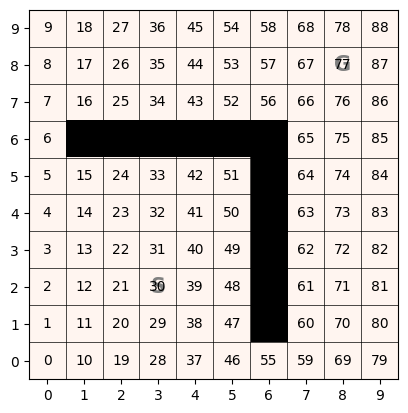

In [22]:
env.image()

## Policy Approximation: Linear Soft-Max In Action Preferences

Use Fourier-basis transformation and set up state-action features.

In [23]:
from gym_classics.algorithms.linear_approximation import transformation_fourier_basis, active_weights

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

def state_features(s,env):
    return trans_fb(env.decode(s))

In [24]:
def state_action_features(s,a,env):
    s = state_features(s,env)
    x = np.zeros(1+len(s)*env.action_space.n)
    x[active_weights(a, len(s)-1)] = s
    return x

Define the preference function $h(s,a,\bf{\theta})=\bf{\theta}^\top \bf{x}(s,a)$

In [25]:
def h(s,a,theta,env):
    return np.dot(theta, state_action_features(s,a,env))

Soft-max transformation from scores to a probability distribution: $\pi(s,a,\theta) = \frac{e^{h(s,a,\bf{\theta})}}{\sum_b h(s,a,\bf{\theta})}$

In [26]:
def pi(s,theta,env):
    hs = np.array([h(s,a,theta,env) for a in range(env.action_space.n)])
    exp_hs = np.exp(hs)
    return exp_hs / np.sum(exp_hs)

Check with a random weight vector.

In [27]:
theta = np.random.rand(1+len(state_features(0, env))*env.action_space.n)
theta

array([0.39, 0.22, 0.51, 0.32, 0.84, 0.97, 0.66, 0.52, 0.09, 0.98, 0.49,
       0.85, 0.03, 0.55, 0.25, 0.27, 0.77, 0.1 , 0.21, 0.63, 0.71, 0.63,
       0.47, 0.17, 0.12, 0.9 , 0.44, 0.63, 0.33, 0.48, 0.28, 0.32, 0.61,
       0.97, 0.79, 0.96, 0.83])

Calculate the preferences score for all actions for state 0.

In [28]:
[h(0,a,theta, env) for a in range(env.action_space.n)] 

[np.float64(4.5268482860522035),
 np.float64(4.592395219880665),
 np.float64(3.4365011129403142),
 np.float64(4.378180633265141)]

Calculate $\pi(s,a,\theta)$ for all actions in state $s=0$

In [29]:
pi(0,theta,env)

array([0.31, 0.33, 0.1 , 0.26])

## REINFORCE

![Pseudocode REINFORCE](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_REINFORCE.png)

We need to sample following a stochastic policy.

In [30]:
def sample_episode_policy(env, pi, theta, max_episode_length=1000):
    """
    Sample an episode using the policy defined by pi and theta.
    Returns a list of (state, action, reward) tuples.
    """
    s, _ = env.reset()
    episode_data = []
    
    for t in range(max_episode_length):
        a = np.random.choice(range(env.action_space.n), p=pi(s,theta,env))
        next_s, r, done, _, _ = env.step(a)
        episode_data.append((s, a, r, next_s))
        s = next_s
        
        if done:
            break
    
    return episode_data


In [31]:
episode_data = sample_episode_policy(env, pi, theta)
episode_data

[(30, np.int64(1), 0.0, 39),
 (39, np.int64(3), 0.0, 30),
 (30, np.int64(3), 0.0, 21),
 (21, np.int64(2), 0.0, 20),
 (20, np.int64(1), 0.0, 29),
 (29, np.int64(1), 0.0, 38),
 (38, np.int64(2), 0.0, 37),
 (37, np.int64(3), 0.0, 28),
 (28, np.int64(1), 0.0, 37),
 (37, np.int64(1), 0.0, 46),
 (46, np.int64(3), 0.0, 37),
 (37, np.int64(0), 0.0, 38),
 (38, np.int64(3), 0.0, 29),
 (29, np.int64(0), 0.0, 30),
 (30, np.int64(0), 0.0, 31),
 (31, np.int64(1), 0.0, 40),
 (40, np.int64(3), 0.0, 31),
 (31, np.int64(3), 0.0, 22),
 (22, np.int64(2), 0.0, 21),
 (21, np.int64(0), 0.0, 22),
 (22, np.int64(1), 0.0, 31),
 (31, np.int64(0), 0.0, 32),
 (32, np.int64(3), 0.0, 23),
 (23, np.int64(1), 0.0, 32),
 (32, np.int64(2), 0.0, 31),
 (31, np.int64(2), 0.0, 30),
 (30, np.int64(1), 0.0, 39),
 (39, np.int64(1), 0.0, 48),
 (48, np.int64(0), 0.0, 49),
 (49, np.int64(1), 0.0, 49),
 (49, np.int64(2), 0.0, 48),
 (48, np.int64(1), 0.0, 48),
 (48, np.int64(3), 0.0, 39),
 (39, np.int64(1), 0.0, 48),
 (48, np.int64

Implement the REINFORCE algorithm. The gradient of the policy for linear approximation is proportional to  $\nabla ln\ \pi(s,a,\bf{\theta}) =   \bf{x}(s,a) - \sum_b \pi(b|s,\bf{\theta}) \bf{x}(s,b)$

In [32]:
from tqdm import tqdm

def REINFORCE(
    env,
    n,
    alpha,
    gamma,
    theta = None,
    max_episode_length=1000,
    verbose=False,
    history=False
    ):
    
    if theta is None:
        theta = np.zeros(1+len(state_features(0, env))*env.action_space.n)
    
    if history:
        returns = []        
        ep_lens = []
        thetas = []
        thetas.append(theta.copy())
        
    for episode in tqdm(range(n), desc="Episodes", disable=verbose):
        if verbose:
            print(f"Episode {episode+1}/{n}")
        
        episode_data = sample_episode_policy(env, pi, theta, max_episode_length)
        
        for t in range(len(episode_data)):
            #print(episode_data[t])
        
            G = np.sum([e[2] for e in episode_data[t:]] * (gamma ** np.arange(len(episode_data[t:]))))
            if history and t == 0:
                returns.append(G)   

            s,a,r,next_s = episode_data[t]
            
            # ln policy gradient= x(s,a)- sum_b pi(b|s,theta) x(s,b)
            grad_log_pi = state_action_features(s, a, env) - sum([pi(s, theta, env)[b] * state_action_features(s, b, env) for b in range(env.action_space.n)])
            
            if verbose: 
                print (f"t: {t}, G: {G:.2f}, grad_log_pi: {grad_log_pi}")
            
            theta += alpha * (gamma**t) * G * grad_log_pi
            
        if history:
            thetas.append(theta.copy())
            ep_lens.append(len(episode_data))
            
    if history:
        return thetas, returns, ep_lens
       
    return theta

In [33]:
thetas, returns, ep_lens = REINFORCE(env, n=500, alpha=0.1, gamma=0.99, history=True)

Episodes: 100%|██████████| 500/500 [00:02<00:00, 180.39it/s]


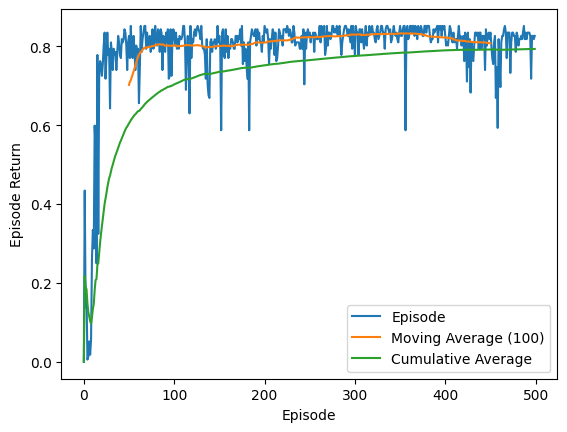

In [34]:
from gym_classics.performance import plot_returns
plot_returns(returns)

Note: MC produces initially high variance.

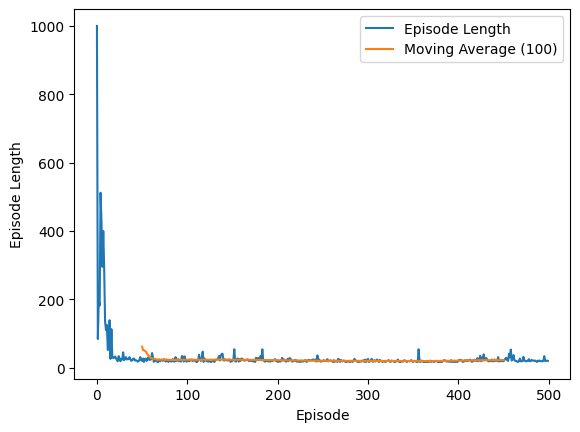

In [35]:
from gym_classics.performance import plot_ep_lens
plot_ep_lens(ep_lens)

In [36]:
#theta = REINFORCE(env, n=500, alpha=0.1, gamma=0.99)
theta = thetas[-1]

## The Learned Policy

In [37]:
pol = [pi(s, theta,env) for s in range(env.observation_space.n)]
pol

[array([9.97e-01, 3.16e-03, 1.86e-04, 3.72e-08]),
 array([9.98e-01, 1.44e-03, 1.90e-04, 1.24e-07]),
 array([1.00e+00, 1.93e-04, 2.10e-04, 3.08e-06]),
 array([1.00e+00, 1.89e-05, 2.70e-04, 2.02e-04]),
 array([9.90e-01, 4.12e-06, 4.41e-04, 9.38e-03]),
 array([9.04e-01, 4.43e-06, 8.88e-04, 9.52e-02]),
 array([8.55e-01, 3.41e-05, 2.38e-03, 1.42e-01]),
 array([0.95, 0.  , 0.01, 0.04]),
 array([0.91, 0.06, 0.02, 0.01]),
 array([3.91e-01, 5.88e-01, 2.10e-02, 3.29e-04]),
 array([9.92e-01, 7.84e-03, 5.15e-04, 2.93e-07]),
 array([9.97e-01, 2.27e-03, 6.76e-04, 3.91e-06]),
 array([9.98e-01, 2.72e-04, 1.05e-03, 2.56e-04]),
 array([9.74e-01, 3.63e-05, 1.99e-03, 2.43e-02]),
 array([5.08e-01, 8.25e-06, 2.54e-03, 4.89e-01]),
 array([1.53e-01, 6.42e-06, 2.16e-03, 8.45e-01]),
 array([0.67, 0.02, 0.06, 0.25]),
 array([0.5 , 0.42, 0.06, 0.01]),
 array([1.15e-01, 8.72e-01, 1.29e-02, 1.71e-04]),
 array([9.11e-01, 8.11e-02, 7.34e-03, 6.62e-05]),
 array([0.96, 0.02, 0.01, 0.  ]),
 array([0.82, 0.  , 0.03, 0.15

Visualize the learned policy by showing the action with the highest probability. The probability is shown using the tile color. 
Closer to 1 means that the algorithm is more sure about the action. Smaller values means that the algorithms still would like to explore.

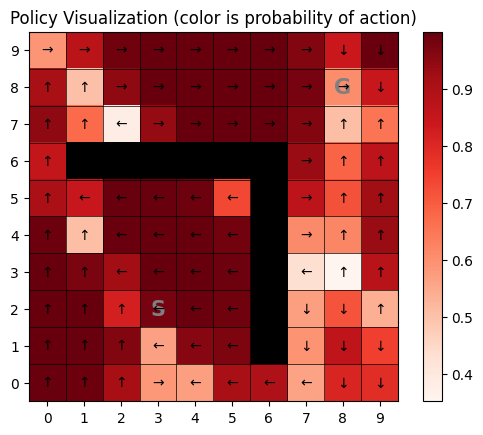

In [38]:
pol_discrete = np.argmax(pol, axis=1)
prob = np.max(pol, axis=1)
env.image(V=prob, policy=pol_discrete, title="Policy Visualization (color is probability of action)")

Visualize the found path using the highest probability action.

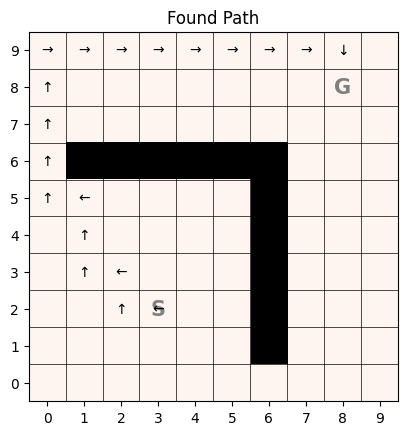

In [39]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol_discrete, max_len=100)
env.image(policy=pol_discrete, episode=path, title='Found Path')


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)